# EDA — Walmart Store Sales Forecasting

Exploratory plots for the project README. Each figure is shown **and** saved under `eda_figures/`.

**Kaggle:** attach competition data · CPU · Internet optional · **Save & Run All**  
After the run, download the `eda_figures/` folder and commit it so README images render on GitHub.

In [1]:
#1 — setup
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams

warnings.filterwarnings("ignore", category=FutureWarning)

FIG_DIR = Path("./eda_figures")
FIG_DIR.mkdir(exist_ok=True)

# Clean academic palette (avoid purple / cream AI defaults)
C = {
    "ink": "#1a2332",
    "muted": "#5c6b7a",
    "line": "#0d6e6e",
    "accent": "#c45c26",
    "accent2": "#2c5f8a",
    "fill": "#d6e8e8",
    "grid": "#e6ebf0",
    "neg": "#b33a3a",
    "years": ["#0d6e6e", "#c45c26", "#2c5f8a", "#6b4c9a"],
}

rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": C["grid"],
    "axes.labelcolor": C["ink"],
    "axes.titlecolor": C["ink"],
    "text.color": C["ink"],
    "xtick.color": C["muted"],
    "ytick.color": C["muted"],
    "axes.grid": True,
    "grid.color": C["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})


def savefig(name, fig=None):
    fig = fig or plt.gcf()
    path = FIG_DIR / name
    fig.savefig(path, dpi=160)
    print(f"saved {path}")
    return path


def millions(x, _pos=None):
    if abs(x) >= 1e6:
        return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


CANDIDATE_DIRS = [
    Path("/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"),
    Path("/kaggle/input/walmart-recruiting-store-sales-forecasting"),
    Path("."),
]
DATA_DIR = next(
    (p for p in CANDIDATE_DIRS if (p / "train.csv").exists() or (p / "train.csv.zip").exists()),
    CANDIDATE_DIRS[0],
)
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting


In [2]:
#2 — load + light enrich
def read_csv(name, **kwargs):
    zipped, plain = DATA_DIR / f"{name}.csv.zip", DATA_DIR / f"{name}.csv"
    return pd.read_csv(zipped if zipped.exists() else plain, **kwargs)

train = read_csv("train", parse_dates=["Date"])
test = read_csv("test", parse_dates=["Date"])
stores = read_csv("stores")
features = read_csv("features", parse_dates=["Date"])

train["IsHoliday"] = train["IsHoliday"].astype(bool)
test["IsHoliday"] = test["IsHoliday"].astype(bool)
features["IsHoliday"] = features["IsHoliday"].astype(bool)

train = train.merge(stores, on="Store", how="left")
train["Year"] = train["Date"].dt.year
train["WeekOfYear"] = train["Date"].dt.isocalendar().week.astype(int)
train["Month"] = train["Date"].dt.month

HOLIDAY_DATES = {
    "Super Bowl": pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"]),
    "Labor Day": pd.to_datetime(["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"]),
    "Thanksgiving": pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"]),
    "Christmas": pd.to_datetime(["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"]),
}

print("train", train.shape, "| test", test.shape, "| stores", stores.shape, "| features", features.shape)
print("date range:", train["Date"].min().date(), "→", train["Date"].max().date())
print("n Store×Dept:", train.groupby(["Store", "Dept"]).ngroups)
train.head()

train (421570, 10) | test (115064, 4) | stores (45, 3) | features (8190, 12)
date range: 2010-02-05 → 2012-10-26
n Store×Dept: 3331


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Year,WeekOfYear,Month
0,1,1,2010-02-05,24924.50,False,A,151315,2010,5,2
1,1,1,2010-02-12,46039.49,True,A,151315,2010,6,2
2,1,1,2010-02-19,41595.55,False,A,151315,2010,7,2
3,1,1,2010-02-26,19403.54,False,A,151315,2010,8,2
4,1,1,2010-03-05,21827.90,False,A,151315,2010,9,3


## 1. წლიური სეზონურობა — ჯამური კვირეული გაყიდვები დროში

ყველა მაღაზია×დეპარტამენტის ჯამი თითოეულ კვირაზე. დღესასწაულური კვირები გამოყოფილია.

saved eda_figures/01_yearly_seasonality_timeline.png


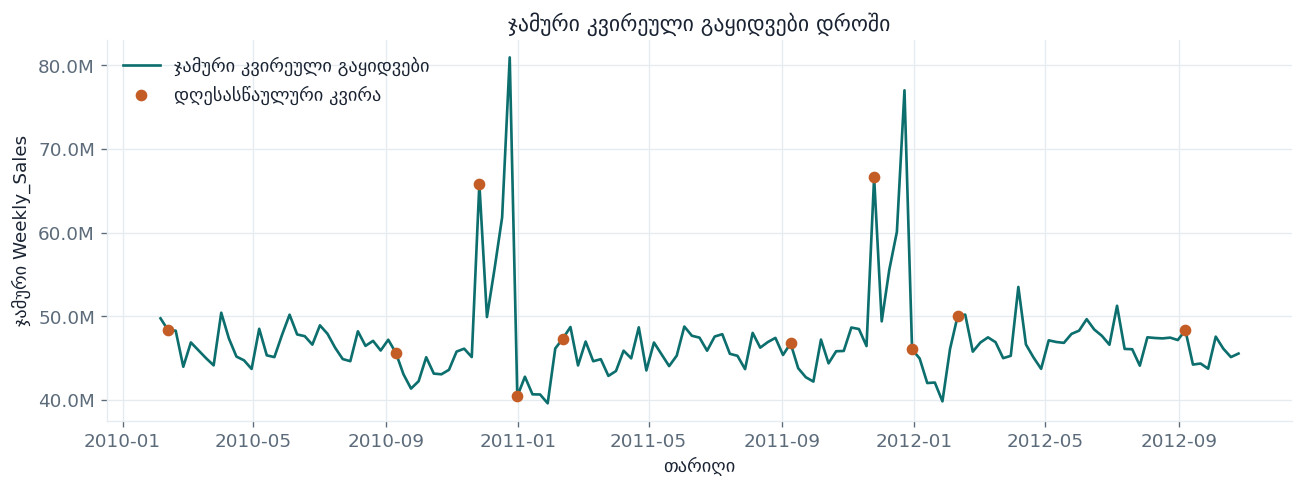

In [3]:
#3 — total weekly sales over time
weekly = (
    train.groupby("Date", as_index=False)
    .agg(Weekly_Sales=("Weekly_Sales", "sum"), IsHoliday=("IsHoliday", "max"))
    .sort_values("Date")
)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(weekly["Date"], weekly["Weekly_Sales"], color=C["line"], lw=1.6, label="ჯამური კვირეული გაყიდვები")
hol = weekly[weekly["IsHoliday"]]
ax.scatter(hol["Date"], hol["Weekly_Sales"], color=C["accent"], s=36, zorder=3, label="დღესასწაულური კვირა")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_title("ჯამური კვირეული გაყიდვები დროში")
ax.set_xlabel("თარიღი")
ax.set_ylabel("ჯამური Weekly_Sales")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
savefig("01_yearly_seasonality_timeline.png")
plt.show()

## 2. იგივე მონაცემი კვირის ნომრის მიხედვით (წლები გადადებული)

სეზონური შაბლონი უფრო ნათლად ჩანს, როცა წლებს ერთმანეთზე ვადებთ კვირის ნომრით.

saved eda_figures/02_seasonality_by_weekofyear.png


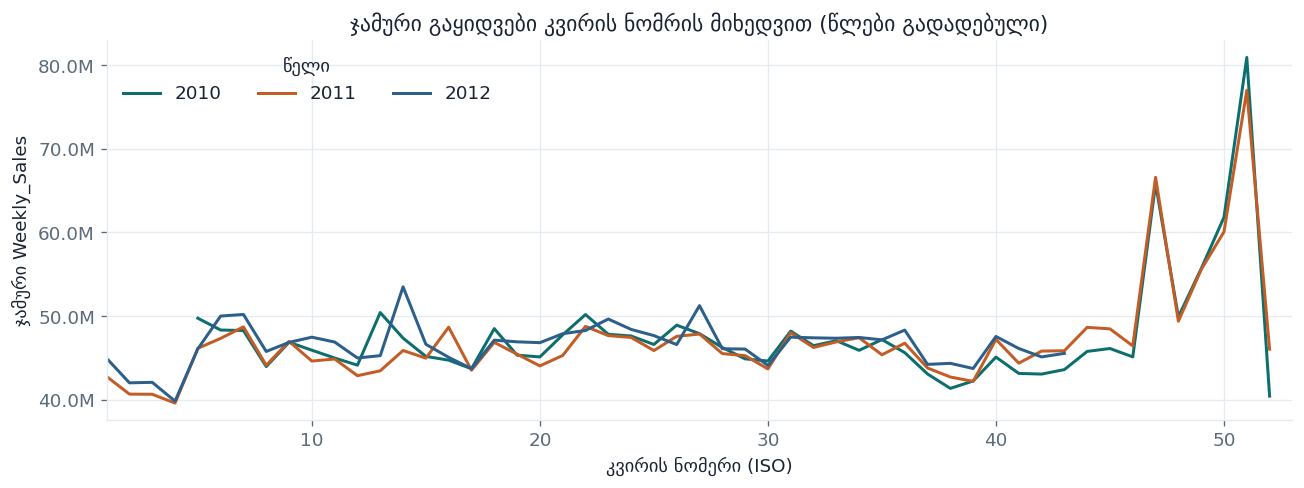

In [4]:
#4 — week-of-year overlay by year
by_woy = (
    train.groupby(["Year", "WeekOfYear"], as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values(["Year", "WeekOfYear"])
)

fig, ax = plt.subplots(figsize=(11, 4.2))
for i, (year, g) in enumerate(by_woy.groupby("Year")):
    ax.plot(
        g["WeekOfYear"], g["Weekly_Sales"],
        color=C["years"][i % len(C["years"])],
        lw=1.8, label=str(year),
    )
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_xlim(1, 53)
ax.set_title("ჯამური გაყიდვები კვირის ნომრის მიხედვით (წლები გადადებული)")
ax.set_xlabel("კვირის ნომერი (ISO)")
ax.set_ylabel("ჯამური Weekly_Sales")
ax.legend(frameon=False, title="წელი", ncol=len(by_woy["Year"].unique()))
fig.tight_layout()
savefig("02_seasonality_by_weekofyear.png")
plt.show()

## 3. არასრული მწკრივები

რამდენი კვირა აქვს თითოეულ `(Store, Dept)` წყვილს ტრენინგში — ბევრი მწკრივი სრული ისტორიის გარეშეა.

სრული კალენდარი: 143 კვირა | მწკრივები: 3331 | არასრული: 671 (20.1%)
saved eda_figures/03_incomplete_series.png


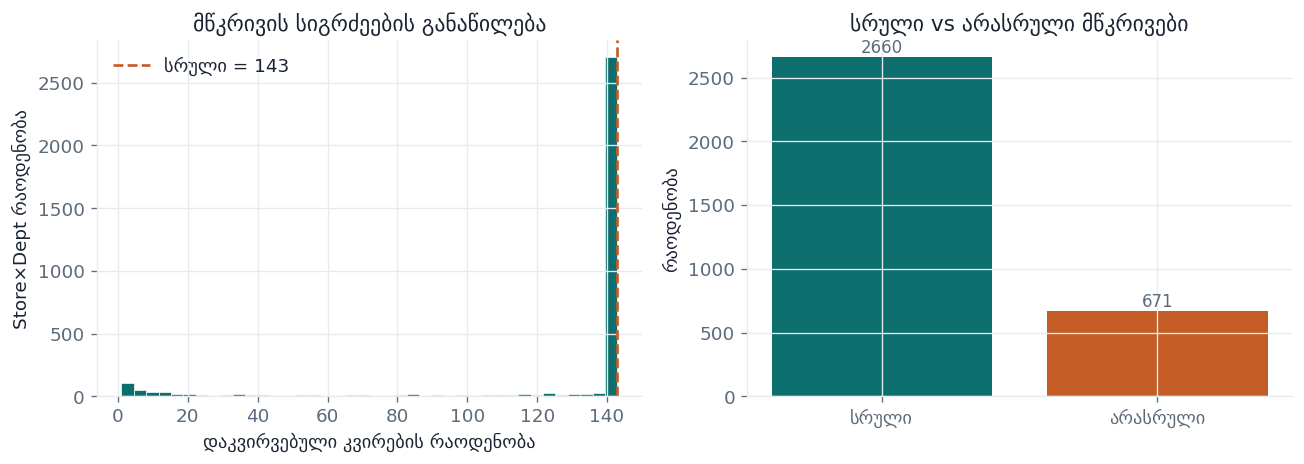

,Store,Dept,n_weeks,complete
3170,43,55,1,False
3224,44,34,1,False
1143,15,99,1,False
1219,16,99,1,False
738,10,77,1,False
1332,18,39,1,False
529,7,99,1,False
1295,17,99,1,False
1340,18,48,1,False
3101,42,34,1,False


In [5]:
#5 — incomplete series lengths
all_fridays = pd.date_range(train["Date"].min(), train["Date"].max(), freq="W-FRI")
n_full = len(all_fridays)

series_len = train.groupby(["Store", "Dept"]).size().rename("n_weeks").reset_index()
series_len["complete"] = series_len["n_weeks"] >= n_full

n_series = len(series_len)
n_incomplete = int((~series_len["complete"]).sum())
print(f"სრული კალენდარი: {n_full} კვირა | მწკრივები: {n_series} | არასრული: {n_incomplete} ({100*n_incomplete/n_series:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].hist(series_len["n_weeks"], bins=40, color=C["line"], edgecolor="white", linewidth=0.4)
axes[0].axvline(n_full, color=C["accent"], ls="--", lw=1.6, label=f"სრული = {n_full}")
axes[0].set_title("მწკრივის სიგრძეების განაწილება")
axes[0].set_xlabel("დაკვირვებული კვირების რაოდენობა")
axes[0].set_ylabel("Store×Dept რაოდენობა")
axes[0].legend(frameon=False)

counts = series_len["complete"].value_counts().rename({True: "სრული", False: "არასრული"})
axes[1].bar(counts.index.astype(str), counts.values, color=[C["line"], C["accent"]])
axes[1].set_title("სრული vs არასრული მწკრივები")
axes[1].set_ylabel("რაოდენობა")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + n_series * 0.01, str(v), ha="center", color=C["muted"], fontsize=10)

fig.tight_layout()
savefig("03_incomplete_series.png")
plt.show()

series_len.sort_values("n_weeks").head(10)

## 4. უარყოფითი გაყიდვები

უარყოფითი `Weekly_Sales` შეიძლება დაბრუნებებს ან კორექციებს ნიშნავდეს — პრეპროცესინგში ჩვეულებრივ 0-მდე იკვეცება.

უარყოფითი რიგები: 1,285 (0.305%) | მინ = -4,988.94
saved eda_figures/04_negative_sales.png


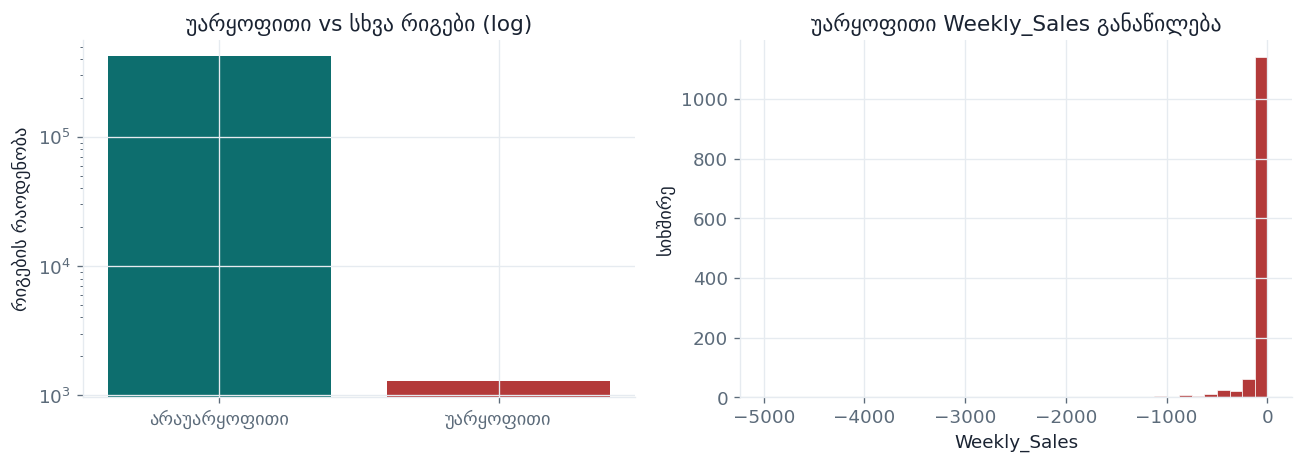

            n_negative
Store Dept            
35    80            25
      47            20
      49            20
10    47            19
42    72            16
39    19            16
35    94            14
20    19            14
32    18            13
17    41            13


In [6]:
#6 — negative sales
neg = train[train["Weekly_Sales"] < 0].copy()
n_neg = len(neg)
pct_neg = 100 * n_neg / len(train)
print(f"უარყოფითი რიგები: {n_neg:,} ({pct_neg:.3f}%) | მინ = {train['Weekly_Sales'].min():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].bar(["არაუარყოფითი", "უარყოფითი"], [len(train) - n_neg, n_neg], color=[C["line"], C["neg"]])
axes[0].set_yscale("log")
axes[0].set_title("უარყოფითი vs სხვა რიგები (log)")
axes[0].set_ylabel("რიგების რაოდენობა")

if n_neg > 0:
    axes[1].hist(neg["Weekly_Sales"], bins=40, color=C["neg"], edgecolor="white", linewidth=0.4)
    axes[1].set_title("უარყოფითი Weekly_Sales განაწილება")
    axes[1].set_xlabel("Weekly_Sales")
    axes[1].set_ylabel("სიხშირე")
else:
    axes[1].text(0.5, 0.5, "უარყოფითი მნიშვნელობები არ არის", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout()
savefig("04_negative_sales.png")
plt.show()

if n_neg:
    top_neg = (
        neg.groupby(["Store", "Dept"]).size()
        .sort_values(ascending=False)
        .head(10)
        .to_frame("n_negative")
    )
    print(top_neg)

## 5. MarkDown და გამოტოვებული მნიშვნელობები

`features.csv`-ში MarkDown1–5 ხშირად ცარიელია (აქციები ყველა კვირაში არ არის).

saved eda_figures/05_markdown_missing.png


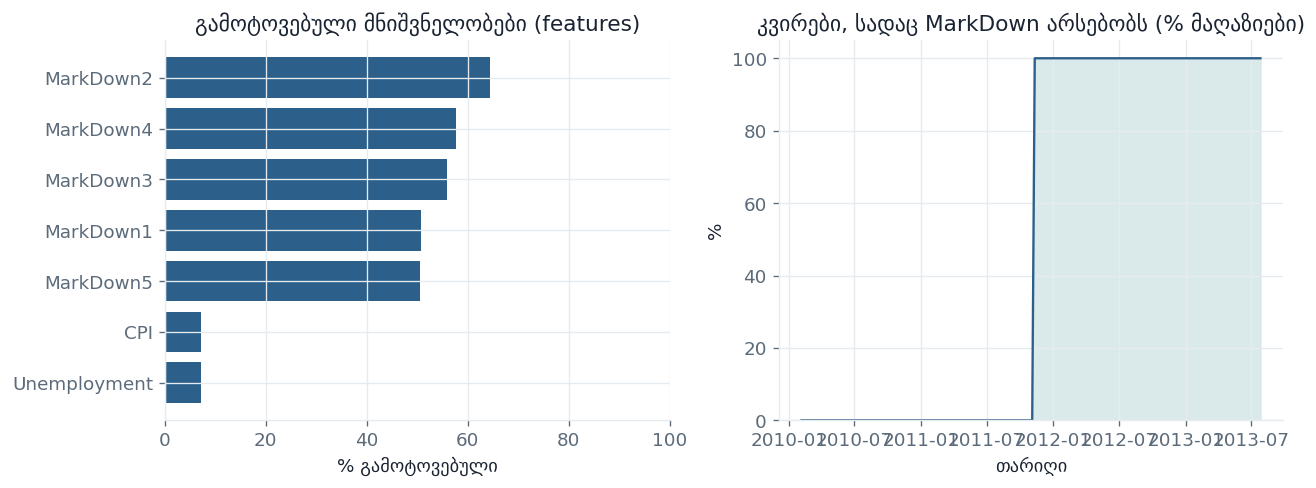

Unemployment     7.1
CPI              7.1
MarkDown5       50.5
MarkDown1       50.8
MarkDown3       55.9
MarkDown4       57.7
MarkDown2       64.3


In [7]:
#7 — MarkDown missingness
md_cols = [c for c in features.columns if c.startswith("MarkDown")]
miss = features[md_cols + ["CPI", "Unemployment"]].isna().mean().sort_values(ascending=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].barh(miss.index, miss.values, color=C["accent2"])
axes[0].set_xlabel("% გამოტოვებული")
axes[0].set_title("გამოტოვებული მნიშვნელობები (features)")
axes[0].set_xlim(0, 100)

# presence over time: share of stores with any MarkDown > 0 or non-null
md = features.copy()
md["any_markdown"] = md[md_cols].notna().any(axis=1)
presence = md.groupby("Date")["any_markdown"].mean() * 100
axes[1].fill_between(presence.index, presence.values, color=C["fill"], alpha=0.9)
axes[1].plot(presence.index, presence.values, color=C["accent2"], lw=1.4)
axes[1].set_ylim(0, 105)
axes[1].set_title("კვირები, სადაც MarkDown არსებობს (% მაღაზიები)")
axes[1].set_ylabel("%")
axes[1].set_xlabel("თარიღი")

fig.tight_layout()
savefig("05_markdown_missing.png")
plt.show()

print(miss.round(1).to_string())

## 6. Weekly_Sales განაწილება

გაყიდვები მკვეთრად მარჯვნივ გადახრილია — ლოგ-სკალა უფრო ინფორმაციულია.

saved eda_figures/06_weekly_sales_distribution.png


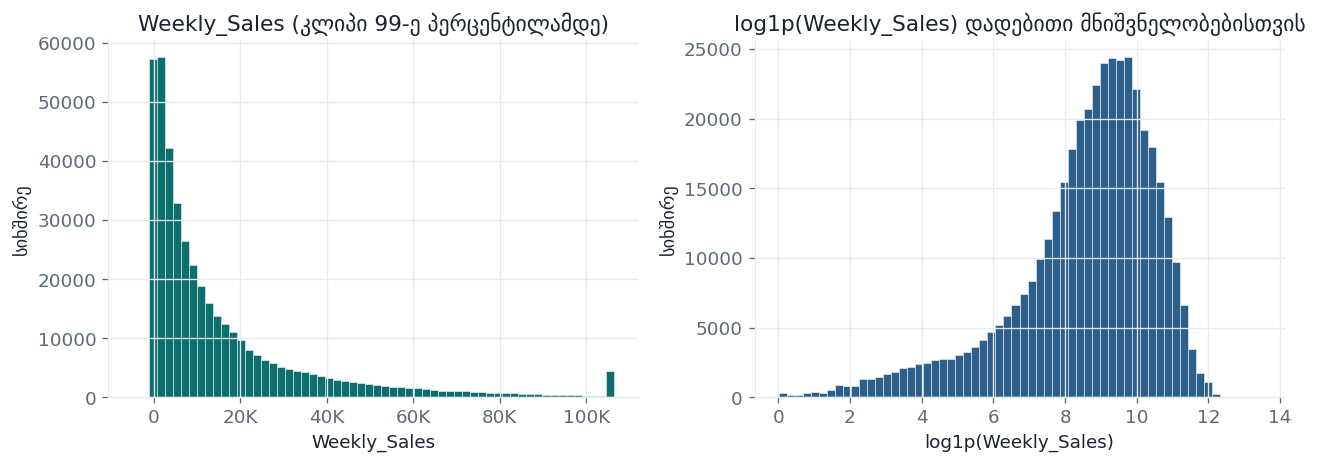

count    421570.00
mean      15981.26
std       22711.18
min       -4988.94
1%            5.00
5%           59.97
50%        7612.03
95%       61201.95
99%      106479.59
max      693099.36
Name: Weekly_Sales, dtype: float64


In [8]:
#8 — Weekly_Sales distribution
y = train["Weekly_Sales"]
y_pos = y[y > 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].hist(y.clip(upper=y.quantile(0.99)), bins=60, color=C["line"], edgecolor="white", linewidth=0.3)
axes[0].set_title("Weekly_Sales (კლიპი 99-ე პერცენტილამდე)")
axes[0].set_xlabel("Weekly_Sales")
axes[0].set_ylabel("სიხშირე")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(millions))

axes[1].hist(np.log1p(y_pos), bins=60, color=C["accent2"], edgecolor="white", linewidth=0.3)
axes[1].set_title("log1p(Weekly_Sales) დადებითი მნიშვნელობებისთვის")
axes[1].set_xlabel("log1p(Weekly_Sales)")
axes[1].set_ylabel("სიხშირე")

fig.tight_layout()
savefig("06_weekly_sales_distribution.png")
plt.show()

print(y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

## 7. ავტოკორელაცია ლაგებზე

საშუალო (Store×Dept) კორელაცია `Weekly_Sales`-სა და მის ლაგებს შორის — მოკლე ლაგები და წლიური (`52`) ძლიერია.

saved eda_figures/07_autocorrelation_lags.png


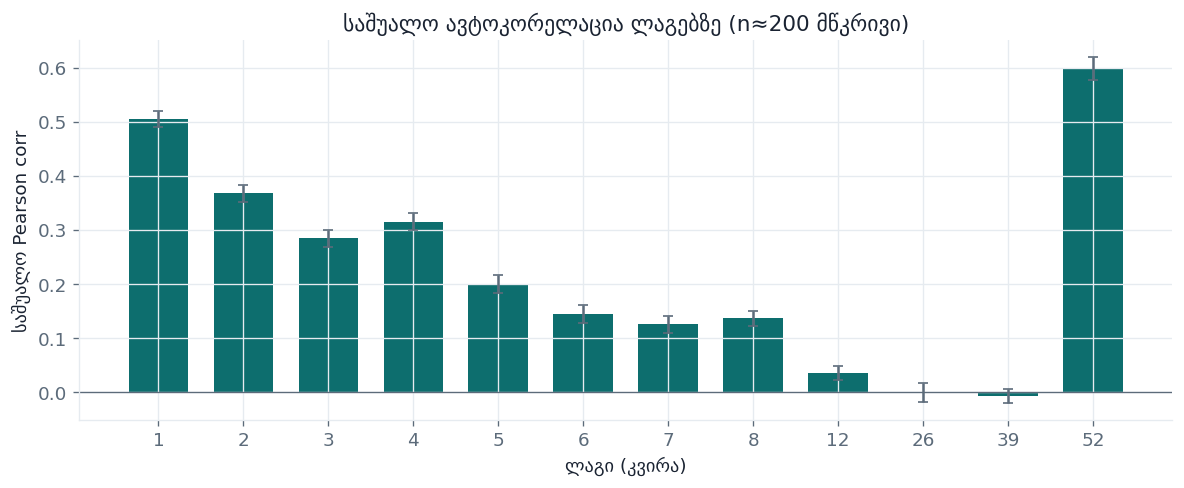

,lag,mean,std,count
0,1,0.505,0.201,200
1,2,0.368,0.223,200
2,3,0.285,0.221,200
3,4,0.315,0.223,200
4,5,0.201,0.232,200
5,6,0.145,0.228,200
6,7,0.126,0.212,200
7,8,0.137,0.206,200
8,12,0.036,0.191,200
9,26,0.000,0.257,200


In [9]:
#9 — autocorrelation by lag (mean across series)
LAGS = [1, 2, 3, 4, 5, 6, 7, 8, 12, 26, 39, 52]

# sample series for speed on Kaggle CPU
rng = np.random.default_rng(42)
pairs = train.groupby(["Store", "Dept"]).size()
pairs = pairs[pairs >= 80].index.tolist()
sample_pairs = [pairs[i] for i in rng.choice(len(pairs), size=min(200, len(pairs)), replace=False)]

acf_rows = []
for store, dept in sample_pairs:
    s = (
        train[(train["Store"] == store) & (train["Dept"] == dept)]
        .sort_values("Date")["Weekly_Sales"]
        .astype(float)
        .reset_index(drop=True)
    )
    if s.std() == 0 or len(s) < 60:
        continue
    for lag in LAGS:
        if len(s) <= lag:
            continue
        corr = s.corr(s.shift(lag))
        if np.isfinite(corr):
            acf_rows.append({"lag": lag, "corr": corr})

acf = pd.DataFrame(acf_rows).groupby("lag")["corr"].agg(["mean", "std", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(acf["lag"].astype(str), acf["mean"], color=C["line"], width=0.7,
       yerr=acf["std"] / np.sqrt(acf["count"]).clip(lower=1), ecolor=C["muted"], capsize=3)
ax.axhline(0, color=C["muted"], lw=0.8)
ax.set_title(f"საშუალო ავტოკორელაცია ლაგებზე (n≈{acf['count'].iloc[0]:.0f} მწკრივი)")
ax.set_xlabel("ლაგი (კვირა)")
ax.set_ylabel("საშუალო Pearson corr")
fig.tight_layout()
savefig("07_autocorrelation_lags.png")
plt.show()

acf.round(3)

## 8. დღესასწაულების ეფექტი

საშუალო გაყიდვები დღესასწაულურ vs ჩვეულებრივ კვირებში — და ოთხი სახელიანი დღესასწაული ცალ-ცალკე.

saved eda_figures/08_holiday_effect.png


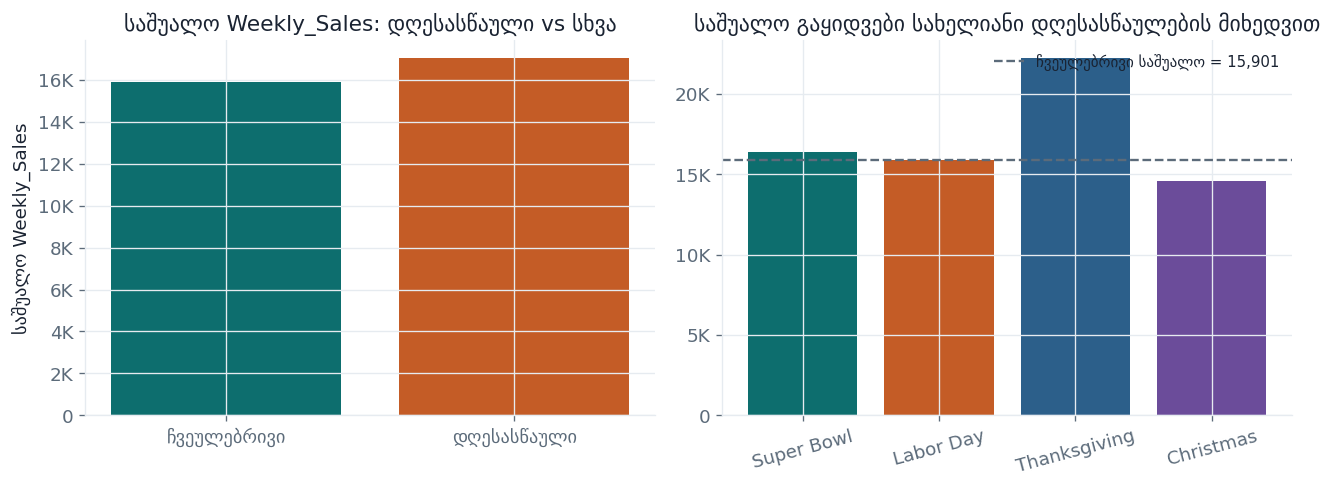

lift vs non-holiday:
HolidayName
Super Bowl       3.0%
Labor Day       -0.1%
Thanksgiving    39.7%
Christmas       -8.5%
Name: Weekly_Sales, dtype: object


In [10]:
#10 — holiday effect
train["HolidayName"] = "None"
for name, dates in HOLIDAY_DATES.items():
    train.loc[train["Date"].isin(dates), "HolidayName"] = name

overall = train.groupby("IsHoliday")["Weekly_Sales"].mean()
by_name = (
    train[train["HolidayName"] != "None"]
    .groupby("HolidayName")["Weekly_Sales"]
    .mean()
    .reindex(list(HOLIDAY_DATES.keys()))
)
baseline = train.loc[~train["IsHoliday"], "Weekly_Sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(["ჩვეულებრივი", "დღესასწაული"], [overall.get(False, 0), overall.get(True, 0)],
            color=[C["line"], C["accent"]])
axes[0].set_title("საშუალო Weekly_Sales: დღესასწაული vs სხვა")
axes[0].set_ylabel("საშუალო Weekly_Sales")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(millions))

colors = [C["years"][i % len(C["years"])] for i in range(len(by_name))]
axes[1].bar(by_name.index, by_name.values, color=colors)
axes[1].axhline(baseline, color=C["muted"], ls="--", lw=1.4, label=f"ჩვეულებრივი საშუალო = {baseline:,.0f}")
axes[1].set_title("საშუალო გაყიდვები სახელიანი დღესასწაულების მიხედვით")
axes[1].tick_params(axis="x", rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(millions))
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
savefig("08_holiday_effect.png")
plt.show()

print("lift vs non-holiday:")
print(((by_name / baseline - 1) * 100).round(1).astype(str) + "%")

## 9. დღესასწაულების ირგვლივ გაყიდვების დინამიკა

საშუალო ჯამური გაყიდვები ±3 კვირა თითოეული დღესასწაულის გარშემო (წლების საშუალო).

saved eda_figures/09_holiday_dynamics.png


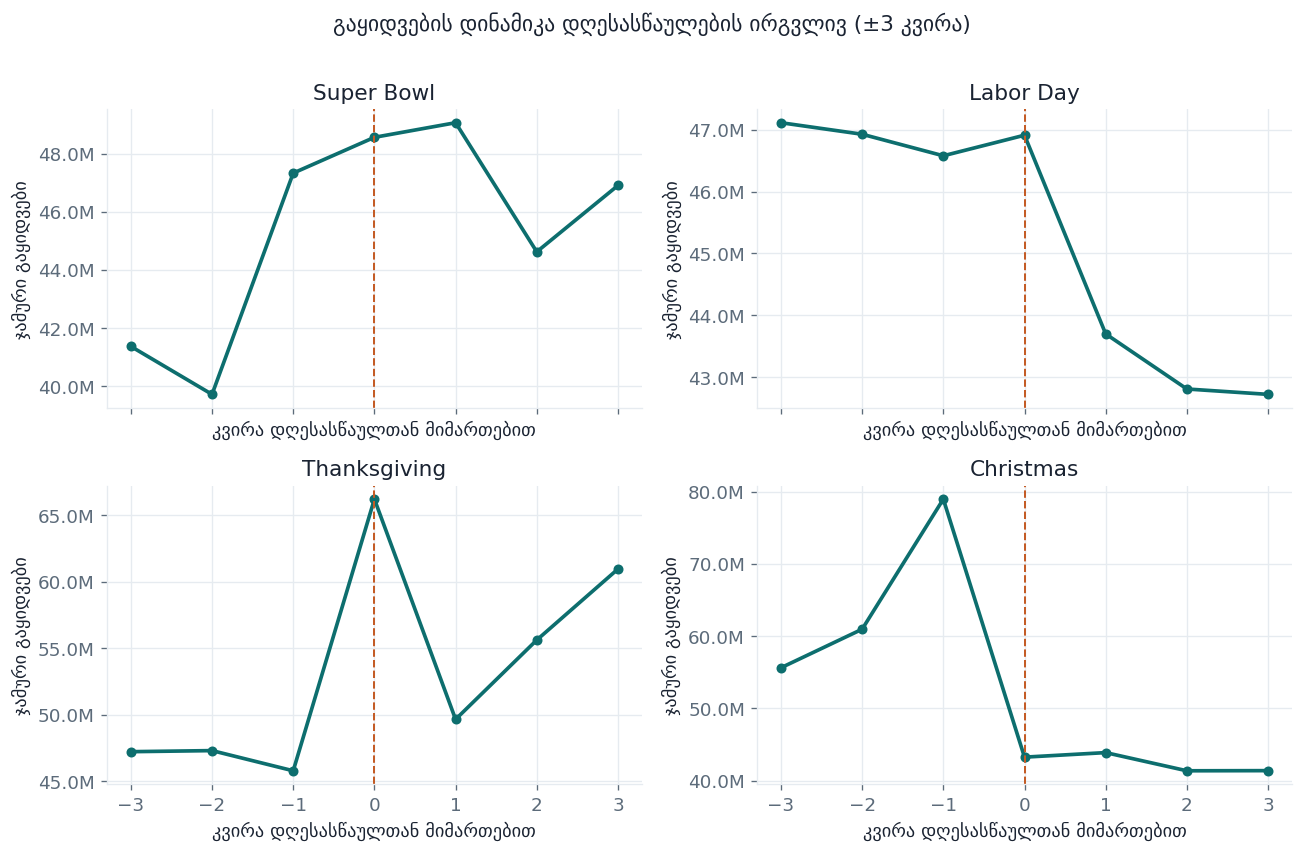

In [11]:
#11 — dynamics around holidays (±3 weeks)
weekly_total = train.groupby("Date")["Weekly_Sales"].sum()
window = range(-3, 4)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.0), sharex=True)
axes = axes.ravel()

for ax, (name, dates) in zip(axes, HOLIDAY_DATES.items()):
    profiles = []
    for d in dates:
        if d < weekly_total.index.min() or d > weekly_total.index.max():
            continue
        vals = []
        for w in window:
            dt = d + pd.Timedelta(weeks=w)
            vals.append(weekly_total.get(dt, np.nan))
        profiles.append(vals)
    mat = np.array(profiles, dtype=float)
    mean = np.nanmean(mat, axis=0)
    ax.plot(list(window), mean, color=C["line"], lw=2.2, marker="o", ms=5)
    ax.axvline(0, color=C["accent"], ls="--", lw=1.2)
    ax.set_title(name)
    ax.set_xlabel("კვირა დღესასწაულთან მიმართებით")
    ax.set_ylabel("ჯამური გაყიდვები")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))

fig.suptitle("გაყიდვების დინამიკა დღესასწაულების ირგვლივ (±3 კვირა)", y=1.01, fontsize=13)
fig.tight_layout()
savefig("09_holiday_dynamics.png")
plt.show()

## 10. Store Size / Type vs Sales

უფრო დიდი მაღაზიები და ტიპები განსხვავებულ საშუალო გაყიდვებს აჩვენებენ.

saved eda_figures/10_store_size_type_vs_sales.png


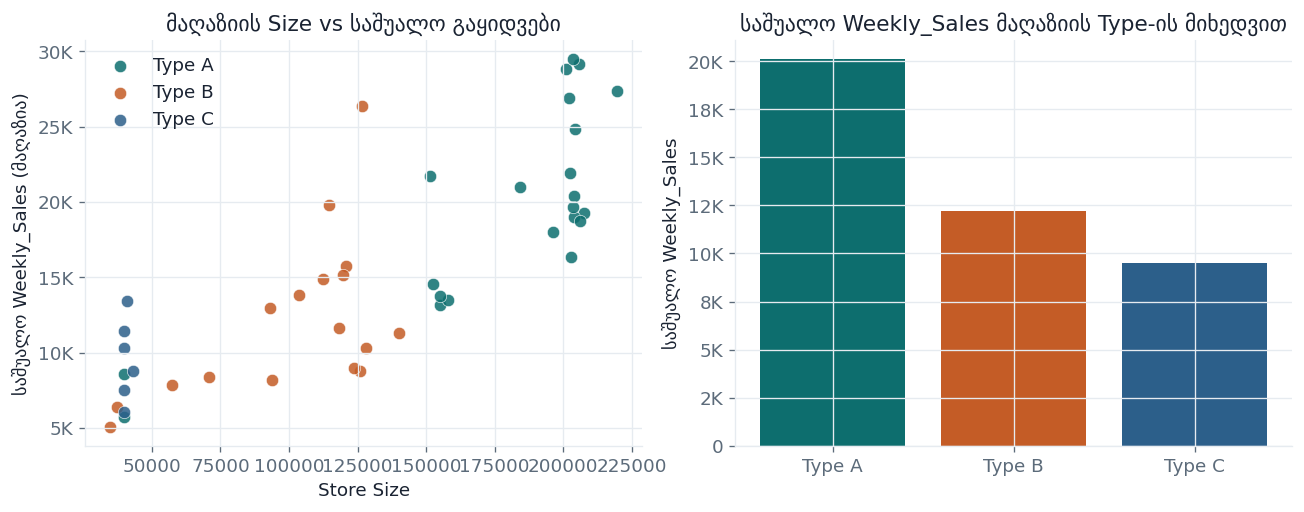

Size                                                            \
     count      mean      std      min       25%       50%       75%   
Type                                                                   
A     22.0  177247.7  49392.6  39690.0  155840.8  202406.0  203819.0   
B     17.0  101190.7  32371.1  34875.0   93188.0  114533.0  123737.0   
C      6.0   40541.7   1304.1  39690.0   39745.0   39910.0   40774.0   

               avg_weekly_sales                                             \
           max            count     mean     std     min      25%      50%   
Type                                                                         
A     219622.0             22.0  19626.2  6523.0  5728.4  15003.5  19479.3   
B     140167.0             17.0  12087.4  5304.1  5053.4   8358.8  11283.4   
C      42988.0              6.0   9575.2  2692.8  6038.9   7810.4   9530.8   

                        
          75%      max  
Type                    
A     24098.5  29508.3  
B     14867.3  26332.3  
C     11156.9  13415.1

In [12]:
#12 — Store Size / Type vs sales
store_sales = (
    train.groupby(["Store", "Type", "Size"], as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "avg_weekly_sales"})
)
type_order = sorted(store_sales["Type"].unique())
type_colors = {t: C["years"][i % len(C["years"])] for i, t in enumerate(type_order)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for t, g in store_sales.groupby("Type"):
    axes[0].scatter(g["Size"], g["avg_weekly_sales"], s=55, alpha=0.85,
                    color=type_colors[t], label=f"Type {t}", edgecolors="white", linewidths=0.4)
axes[0].set_title("მაღაზიის Size vs საშუალო გაყიდვები")
axes[0].set_xlabel("Store Size")
axes[0].set_ylabel("საშუალო Weekly_Sales (მაღაზია)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(millions))
axes[0].legend(frameon=False)

type_avg = train.groupby("Type")["Weekly_Sales"].mean().reindex(type_order)
axes[1].bar([f"Type {t}" for t in type_avg.index], type_avg.values,
            color=[type_colors[t] for t in type_avg.index])
axes[1].set_title("საშუალო Weekly_Sales მაღაზიის Type-ის მიხედვით")
axes[1].set_ylabel("საშუალო Weekly_Sales")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(millions))

fig.tight_layout()
savefig("10_store_size_type_vs_sales.png")
plt.show()

store_sales.groupby("Type")[["Size", "avg_weekly_sales"]].describe().round(1)

## შენახული ფაილები

გადმოწერეთ `eda_figures/` და ჩააგდეთ რეპოზიტორში — README ამ გზებს იყენებს.

In [13]:
#13 — list saved figures
files = sorted(FIG_DIR.glob("*.png"))
for p in files:
    print(f"{p.name:45s}  {p.stat().st_size/1024:7.1f} KB")
print(f"\n{len(files)} figures in {FIG_DIR.resolve()}")

01_yearly_seasonality_timeline.png               121.4 KB
02_seasonality_by_weekofyear.png                 138.8 KB
03_incomplete_series.png                          91.7 KB
04_negative_sales.png                             72.9 KB
05_markdown_missing.png                           90.2 KB
06_weekly_sales_distribution.png                  90.9 KB
07_autocorrelation_lags.png                       57.2 KB
08_holiday_effect.png                            105.9 KB
09_holiday_dynamics.png                          196.6 KB
10_store_size_type_vs_sales.png                  115.5 KB

10 figures in /kaggle/working/eda_figures
